# Task 1 — Prove why we visualize (`datasaurus.csv`)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.titlesize":13,"axes.titleweight":"bold","axes.titlelocation":"left"})
NOTE = lambda fig, s: fig.text(0.01, -0.02, s, fontsize=9, color="dimgray", ha="left")   # exclusions / assumptions on the chart
df = pd.read_csv("datasaurus.csv")
print(df.shape, df.dataset.nunique(), "datasets;", df.groupby("dataset").size().unique(), "points each")

(1846, 3) 13 datasets; [142] points each


## 1. Summary statistics per dataset
Assumption: standard deviation is the sample SD (n−1); correlation is Pearson.

In [2]:
g = df.groupby("dataset")
stats = pd.DataFrame({"mean_x": g.x.mean(), "mean_y": g.y.mean(), "sd_x": g.x.std(), "sd_y": g.y.std(),
                      "corr_xy": g[["x","y"]].apply(lambda d: d.x.corr(d.y))})
display(stats.round(2))
print("Largest difference between any two datasets (unrounded):"); print((stats.max()-stats.min()).round(3).to_string())

,mean_x,mean_y,sd_x,sd_y,corr_xy
dataset,,,,,
away,54.27,47.83,16.77,26.94,-0.06
bullseye,54.27,47.83,16.77,26.94,-0.07
circle,54.27,47.84,16.76,26.93,-0.07
dino,54.26,47.83,16.77,26.94,-0.06
dots,54.26,47.84,16.77,26.93,-0.06
h_lines,54.26,47.83,16.77,26.94,-0.06
high_lines,54.27,47.84,16.77,26.94,-0.07
slant_down,54.27,47.84,16.77,26.94,-0.07
slant_up,54.27,47.83,16.77,26.94,-0.07


Largest difference between any two datasets (unrounded):
mean_x     0.010
mean_y     0.010
sd_x       0.010
sd_y       0.010
corr_xy    0.009


## 2. Conclusion if the table were all I had
All 13 datasets are essentially the same: the same centre (means), the same spread (SDs) and the same very weak, slightly negative linear relationship between x and y (correlation near 0). I would conclude there is one kind of data here and nothing to distinguish the datasets.

## 3. All 13 as scatter plots

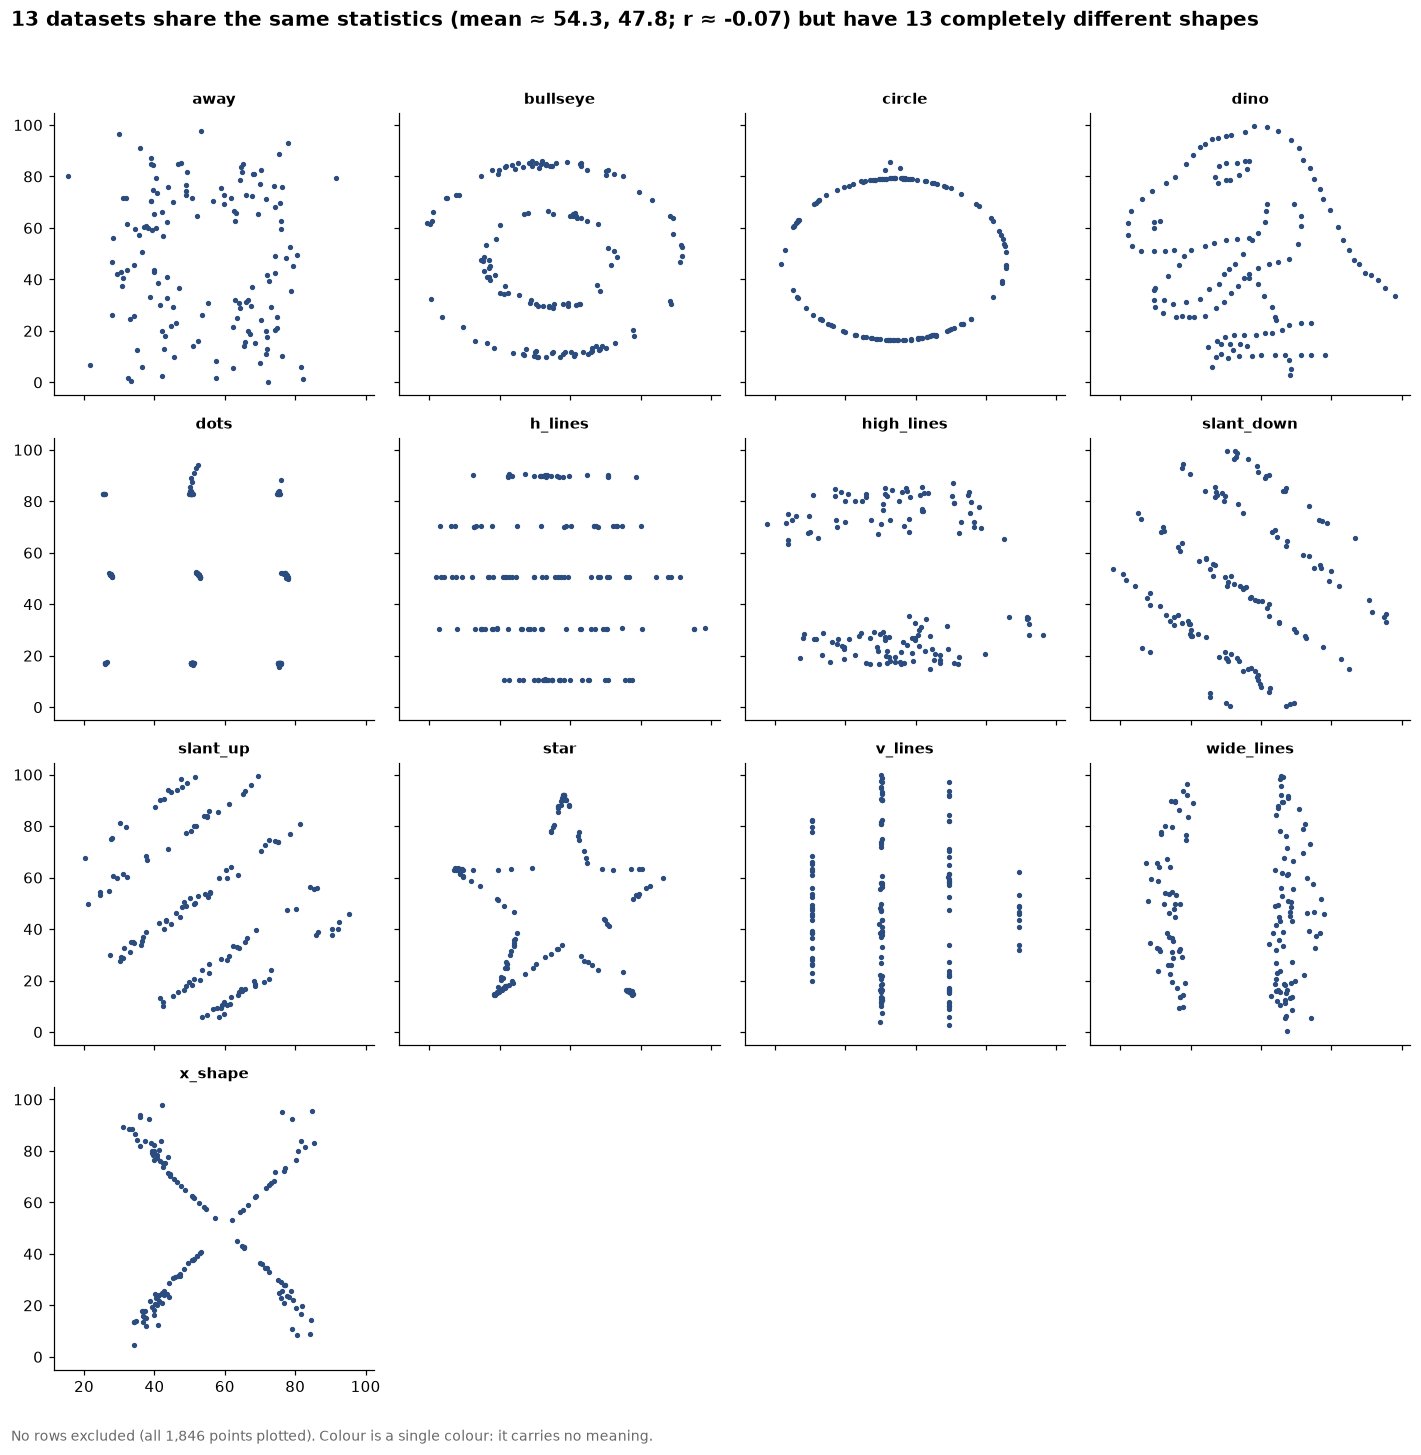

In [3]:
names = list(stats.index)
fig, axes = plt.subplots(4, 4, figsize=(13, 13), sharex=True, sharey=True)
for ax, n in zip(axes.ravel(), names):
    d = df[df.dataset == n]; ax.scatter(d.x, d.y, s=6, color="#2b4c7e"); ax.set_title(n, fontsize=10, loc="center")
for ax in axes.ravel()[len(names):]: ax.axis("off")
fig.suptitle(f"13 datasets share the same statistics (mean ≈ {stats.mean_x.mean():.1f}, {stats.mean_y.mean():.1f}; "
             f"r ≈ {stats.corr_xy.mean():.2f}) but have 13 completely different shapes", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.96]); NOTE(fig, "No rows excluded (all 1,846 points plotted). Colour is a single colour: it carries no meaning."); plt.show()

## 4. What I found
The statistics in the table are identical to two decimal places, yet the plots show a dinosaur, a star, a circle, parallel lines, a cross and others, plus a plain cloud. The numbers describe a centre, a spread and a straight-line trend; they say nothing about shape, clusters, lines or outliers, and a correlation near 0 does not mean "no pattern" (the star and the lines are clearly structured). Only the plots reveal what the data is.

## Question: do 13 datasets with 142 points each make the summary statistics more trustworthy?
**No.** More datasets and more points do not fix the problem, because the problem is not noise or sample size: it is that a handful of summary numbers throws away the shape of the data. With 142 points per dataset the statistics are *more precisely* the same, and the 13 plots still look nothing alike; 13 examples only gives 13 demonstrations of the same failure (and, as with Anscombe's, the datasets were constructed to match, which is the point). Statistics are reliable only for the question they answer (centre, spread, linear trend) and only once a plot has shown that those are the right questions to ask.